Exact probability P(sum > 9) = 0.1666666667

Monte Carlo estimator:
I_k = 1 if the sum of the two dice is greater than 9, and 0 otherwise.
p_hat = (1/N) * sum(I_k)

N        | estimate         | absolute error   | theoretical std
----------------------------------------------------------------------
     100 |     0.2300000000 |     0.0633333333 |   0.0372677996
    1000 |     0.1780000000 |     0.0113333333 |   0.0117851130
   10000 |     0.1716000000 |     0.0049333333 |   0.0037267800
  100000 |     0.1662400000 |     0.0004266667 |   0.0011785113
 1000000 |     0.1661110000 |     0.0005556667 |   0.0003726780
10000000 |     0.1666924000 |     0.0000257333 |   0.0001178511


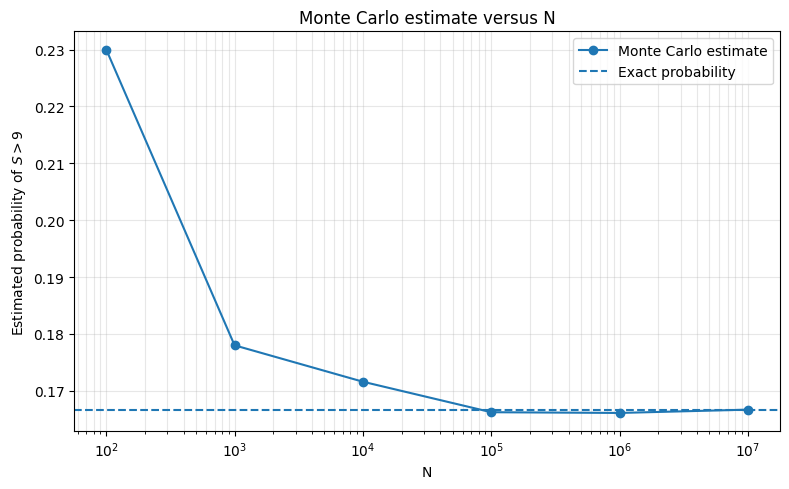

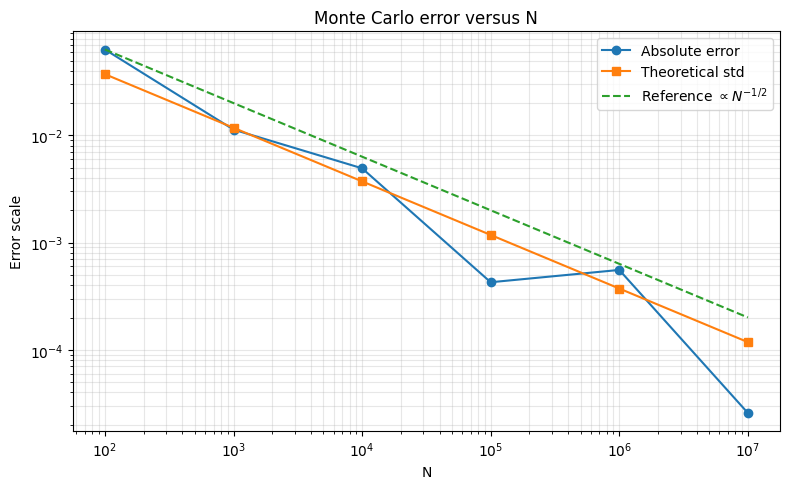

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Define the random seed used to make the simulation reproducible.
SEED = 10

# Define the sample sizes requested for the Monte Carlo study.
N_VALUES = np.array([10**2, 10**3, 10**4, 10**5, 10**6, 10**7], dtype=int)


def exact_probability() -> float:
    """Return the exact probability that the sum of two fair dice is greater than 9.

    The favorable sums are:
        10 -> 3 outcomes
        11 -> 2 outcomes
        12 -> 1 outcome

    Total favorable outcomes = 6
    Total equally likely outcomes = 36

    Returns:
        Exact probability of the event.
    """
    # Compute the exact probability from the analytical count.
    return 6.0 / 36.0


def theoretical_std(n: int, p: float) -> float:
    """Return the theoretical standard deviation of the Monte Carlo estimator.

    For an indicator estimator:
        I_hat = (1 / N) * sum(I_k)

    where I_k is Bernoulli(p), we have:
        Var(I_hat) = p * (1 - p) / N

    Args:
        n: Number of Monte Carlo simulations.
        p: True probability of the event.

    Returns:
        Theoretical standard deviation of the estimator.
    """
    # Compute the theoretical standard deviation of the Monte Carlo estimator.
    return np.sqrt(p * (1.0 - p) / n)


def monte_carlo_estimate(n: int, seed: int) -> float:
    """Estimate the probability that the sum of two fair dice is greater than 9.

    The algorithm is:
        1. Generate the result of die 1.
        2. Generate the result of die 2.
        3. Compute the sum.
        4. Mark success when the sum is strictly greater than 9.
        5. Return the relative frequency of success.

    Args:
        n: Number of Monte Carlo simulations.
        seed: Seed used by the random number generator.

    Returns:
        Monte Carlo estimate of the probability.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Generate n outcomes for the first die, each uniformly distributed from 1 to 6.
    die_1 = rng.integers(1, 7, size=n)

    # Generate n outcomes for the second die, each uniformly distributed from 1 to 6.
    die_2 = rng.integers(1, 7, size=n)

    # Compute the sum of the two dice in every experiment.
    sums = die_1 + die_2

    # Build the indicator of success for the event sum > 9.
    success = sums > 9

    # Return the relative frequency of success.
    return np.mean(success)


def main() -> None:
    """Run the analytical comparison and Monte Carlo simulation."""
    # Compute the exact probability.
    exact_value = exact_probability()

    # Print the exact value before the simulations.
    print(f"Exact probability P(sum > 9) = {exact_value:.10f}")
    print()

    # Explain the Monte Carlo estimator used in the code.
    print("Monte Carlo estimator:")
    print("I_k = 1 if the sum of the two dice is greater than 9, and 0 otherwise.")
    print("p_hat = (1/N) * sum(I_k)")
    print()

    # Create empty Python lists to store the estimates.
    estimates = []

    # Create empty Python lists to store the absolute errors.
    absolute_errors = []

    # Create empty Python lists to store the theoretical standard deviations.
    theoretical_stds = []

    # Print a header for the numerical results.
    print("N        | estimate         | absolute error   | theoretical std")
    print("-" * 70)

    # Loop over all requested sample sizes.
    for n in N_VALUES:
        # Compute the Monte Carlo estimate for the current sample size.
        estimate = monte_carlo_estimate(n=n, seed=SEED + n)

        # Compute the absolute error relative to the exact probability.
        absolute_error = abs(estimate - exact_value)

        # Compute the theoretical standard deviation of the estimator.
        std_value = theoretical_std(n=n, p=exact_value)

        # Store the estimate for later analysis and plotting.
        estimates.append(estimate)

        # Store the absolute error for later plotting.
        absolute_errors.append(absolute_error)

        # Store the theoretical standard deviation for reference.
        theoretical_stds.append(std_value)

        # Print the current results.
        print(f"{n:8d} | {estimate:16.10f} | {absolute_error:16.10f} | {std_value:14.10f}")

    # Convert the stored estimates to a NumPy array.
    estimates = np.array(estimates)

    # Convert the stored absolute errors to a NumPy array.
    absolute_errors = np.array(absolute_errors)

    # Convert the stored theoretical standard deviations to a NumPy array.
    theoretical_stds = np.array(theoretical_stds)

    # Create a reference curve proportional to N^(-1/2) to compare the trend.
    reference_curve = absolute_errors[0] * np.sqrt(N_VALUES[0] / N_VALUES)

    # Create a figure for the estimate versus N.
    plt.figure(figsize=(8, 5))

    # Plot the Monte Carlo estimate for each N.
    plt.semilogx(N_VALUES, estimates, marker="o", label="Monte Carlo estimate")

    # Plot the exact probability as a horizontal reference line.
    plt.axhline(exact_value, linestyle="--", label="Exact probability")

    # Label the horizontal axis.
    plt.xlabel("N")

    # Label the vertical axis.
    plt.ylabel(r"Estimated probability of $S > 9$")

    # Add a title to the plot.
    plt.title("Monte Carlo estimate versus N")

    # Add a grid to improve readability.
    plt.grid(True, which="both", alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout to avoid clipping.
    plt.tight_layout()

    # Create a figure for the absolute error versus N.
    plt.figure(figsize=(8, 5))

    # Plot the absolute error on log-log axes.
    plt.loglog(N_VALUES, absolute_errors, marker="o", label="Absolute error")

    # Plot the theoretical standard deviation on log-log axes.
    plt.loglog(N_VALUES, theoretical_stds, marker="s", label="Theoretical std")

    # Plot a generic N^(-1/2) reference curve.
    plt.loglog(N_VALUES, reference_curve, linestyle="--", label=r"Reference $\propto N^{-1/2}$")

    # Label the horizontal axis.
    plt.xlabel("N")

    # Label the vertical axis.
    plt.ylabel("Error scale")

    # Add a title to the plot.
    plt.title("Monte Carlo error versus N")

    # Add a grid to improve readability.
    plt.grid(True, which="both", alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout to avoid clipping.
    plt.tight_layout()

    # Show all generated figures.
    plt.show()


main()